In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo consistente para todos los plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✓ Setup listo")

✓ Setup listo


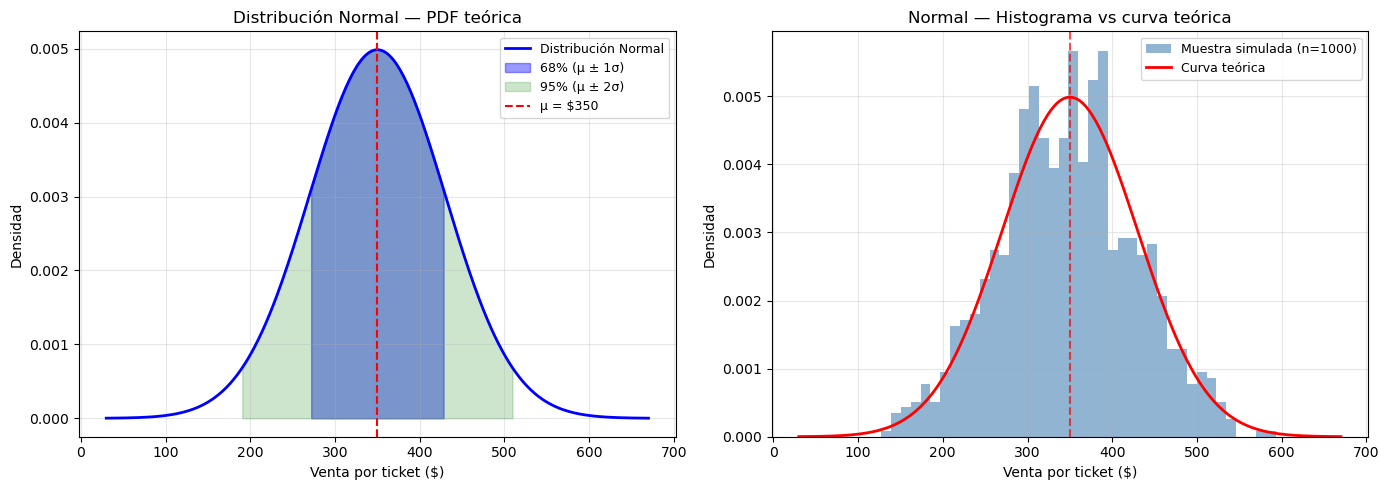

μ = 350, σ = 80
Rango 68%: $270 – $430
Rango 95%: $190 – $510
Rango 99.7%: $110 – $590


In [2]:
# ============================================================
# S4.2 — DISTRIBUCIÓN NORMAL
# ============================================================

# Parámetros: media (μ) y desviación estándar (σ)
# Forma: campana simétrica centrada en μ
# Regla 68-95-99.7: 68% de datos en μ±σ, 95% en μ±2σ, 99.7% en μ±3σ

mu = 350      # media: ticket promedio del restaurante
sigma = 80    # desviación estándar

# Generar la curva teórica
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
pdf = stats.norm.pdf(x, mu, sigma)   # PDF = densidad de probabilidad

# Generar muestra simulada
muestra = np.random.normal(mu, sigma, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Curva teórica con zonas ---
ax = axes[0]
ax.plot(x, pdf, 'b-', linewidth=2, label='Distribución Normal')
ax.fill_between(x, pdf, where=(x >= mu-sigma) & (x <= mu+sigma),
                alpha=0.4, color='blue', label='68% (μ ± 1σ)')
ax.fill_between(x, pdf, where=(x >= mu-2*sigma) & (x <= mu+2*sigma),
                alpha=0.2, color='green', label='95% (μ ± 2σ)')
ax.axvline(mu, color='red', linestyle='--', label=f'μ = ${mu}')
ax.set_title('Distribución Normal — PDF teórica')
ax.set_xlabel('Venta por ticket ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)

# --- Plot 2: Histograma de muestra vs curva teórica ---
ax = axes[1]
ax.hist(muestra, bins=40, density=True, alpha=0.6, color='steelblue',
        label='Muestra simulada (n=1000)')
ax.plot(x, pdf, 'r-', linewidth=2, label='Curva teórica')
ax.axvline(mu, color='red', linestyle='--', alpha=0.7)
ax.set_title('Normal — Histograma vs curva teórica')
ax.set_xlabel('Venta por ticket ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/S4.2_normal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"μ = {mu}, σ = {sigma}")
print(f"Rango 68%: ${mu-sigma:.0f} – ${mu+sigma:.0f}")
print(f"Rango 95%: ${mu-2*sigma:.0f} – ${mu+2*sigma:.0f}")
print(f"Rango 99.7%: ${mu-3*sigma:.0f} – ${mu+3*sigma:.0f}")

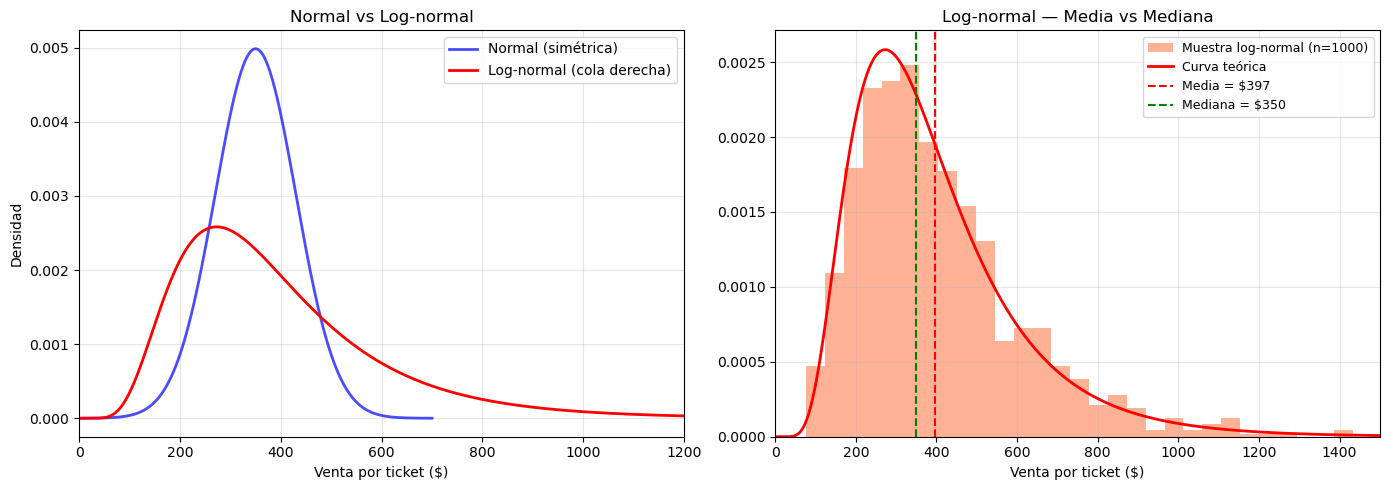

Media teórica:   $397
Mediana teórica: $350
Diferencia:      $47  ← cola derecha infla la media


In [3]:
# ============================================================
# S4.2 — DISTRIBUCIÓN LOG-NORMAL
# ============================================================

# Cuando una variable es el PRODUCTO de muchos factores pequeños → log-normal
# Ejemplos reales: tickets de venta, ingresos, precios, tiempos de respuesta
# Característica: cola larga a la derecha (como viste en Leonali y Farmacias)

# Parámetros: mu y sigma del logaritmo de los datos
mu_log = np.log(350)   # log de la media real
sigma_log = 0.5        # controla el "sesgo" hacia la derecha

x = np.linspace(0.01, 2000, 1000)
pdf_log = stats.lognorm.pdf(x, s=sigma_log, scale=np.exp(mu_log))

muestra_log = np.random.lognormal(mu_log, sigma_log, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Log-normal vs Normal ---
ax = axes[0]
mu_n, sigma_n = 350, 80
x_n = np.linspace(0, 700, 300)
ax.plot(x_n, stats.norm.pdf(x_n, mu_n, sigma_n), 'b-',
        linewidth=2, label='Normal (simétrica)', alpha=0.7)
ax.plot(x, pdf_log, 'r-', linewidth=2, label='Log-normal (cola derecha)')
ax.set_xlim(0, 1200)
ax.set_title('Normal vs Log-normal')
ax.set_xlabel('Venta por ticket ($)')
ax.set_ylabel('Densidad')
ax.legend()

# --- Plot 2: Histograma real de muestra log-normal ---
ax = axes[1]
ax.hist(muestra_log, bins=50, density=True, alpha=0.6,
        color='coral', label='Muestra log-normal (n=1000)')
ax.plot(x, pdf_log, 'r-', linewidth=2, label='Curva teórica')
media_real = np.exp(mu_log + sigma_log**2 / 2)
mediana_real = np.exp(mu_log)
ax.axvline(media_real, color='red', linestyle='--',
           label=f'Media = ${media_real:.0f}')
ax.axvline(mediana_real, color='green', linestyle='--',
           label=f'Mediana = ${mediana_real:.0f}')
ax.set_xlim(0, 1500)
ax.set_title('Log-normal — Media vs Mediana')
ax.set_xlabel('Venta por ticket ($)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/S4.2_lognormal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Media teórica:   ${media_real:.0f}")
print(f"Mediana teórica: ${mediana_real:.0f}")
print(f"Diferencia:      ${media_real - mediana_real:.0f}  ← cola derecha infla la media")

λ= 2 | P(exactamente 2 compras) = 0.271 (27.1%)
λ= 5 | P(exactamente 5 compras) = 0.175 (17.5%)
λ=15 | P(exactamente 15 compras) = 0.102 (10.2%)


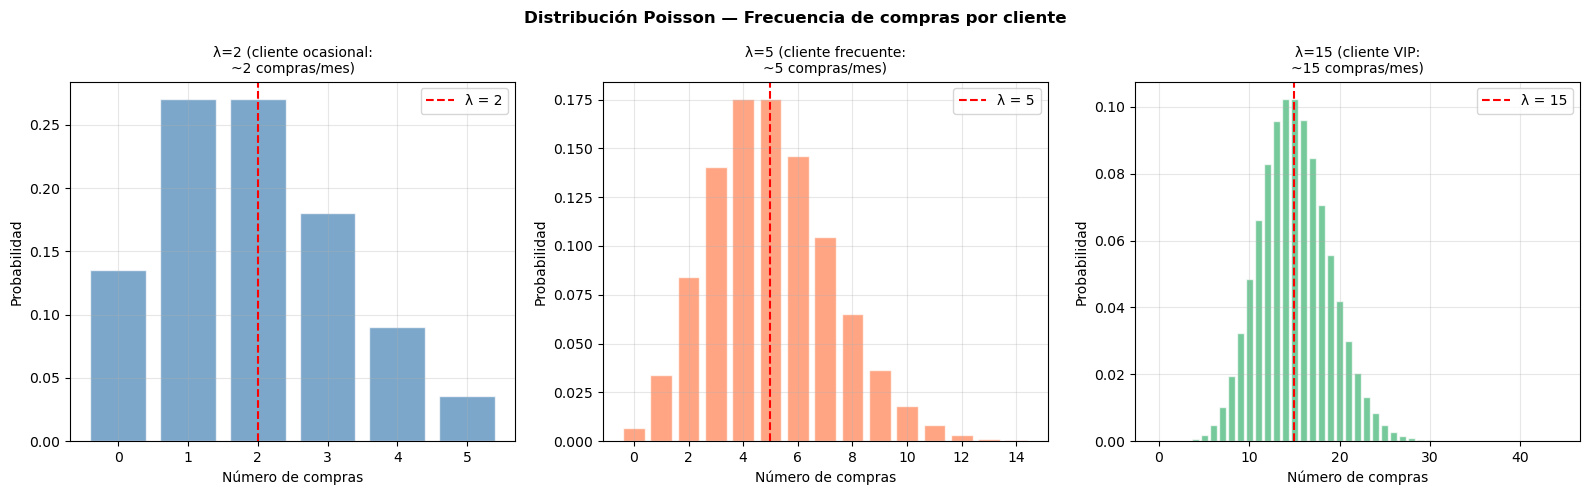

In [13]:
# ============================================================
# S4.2 — DISTRIBUCIÓN POISSON
# ============================================================

# Modela: número de eventos en un intervalo fijo de tiempo/espacio
# Condición: eventos independientes, tasa promedio constante (λ)
# Ejemplos retail: compras por cliente por mes, visitas por hora,
#                  productos por ticket

# Parámetro: λ (lambda) = promedio de eventos esperados

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lambdas = [2, 5, 15]   # λ pequeño, medio, grande
titulos = ['λ=2 (cliente ocasional:\n~2 compras/mes)',
           'λ=5 (cliente frecuente:\n~5 compras/mes)',
           'λ=15 (cliente VIP:\n~15 compras/mes)']
colores = ['steelblue', 'coral', 'mediumseagreen']

for i, (lam, titulo, color) in enumerate(zip(lambdas, titulos, colores)):
    ax = axes[i]
    k = np.arange(0, lam*3)
    probs = stats.poisson.pmf(k, lam)   # PMF = probabilidad en punto exacto

    ax.bar(k, probs, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(lam, color='red', linestyle='--', linewidth=1.5,
               label=f'λ = {lam}')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Número de compras')
    ax.set_ylabel('Probabilidad')
    ax.legend()

    # Probabilidad de exactamente λ compras
    p_exacta = stats.poisson.pmf(lam, lam)
    print(f"λ={lam:2d} | P(exactamente {lam} compras) = {p_exacta:.3f} ({p_exacta*100:.1f}%)")

plt.suptitle('Distribución Poisson — Frecuencia de compras por cliente',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/S4.2_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

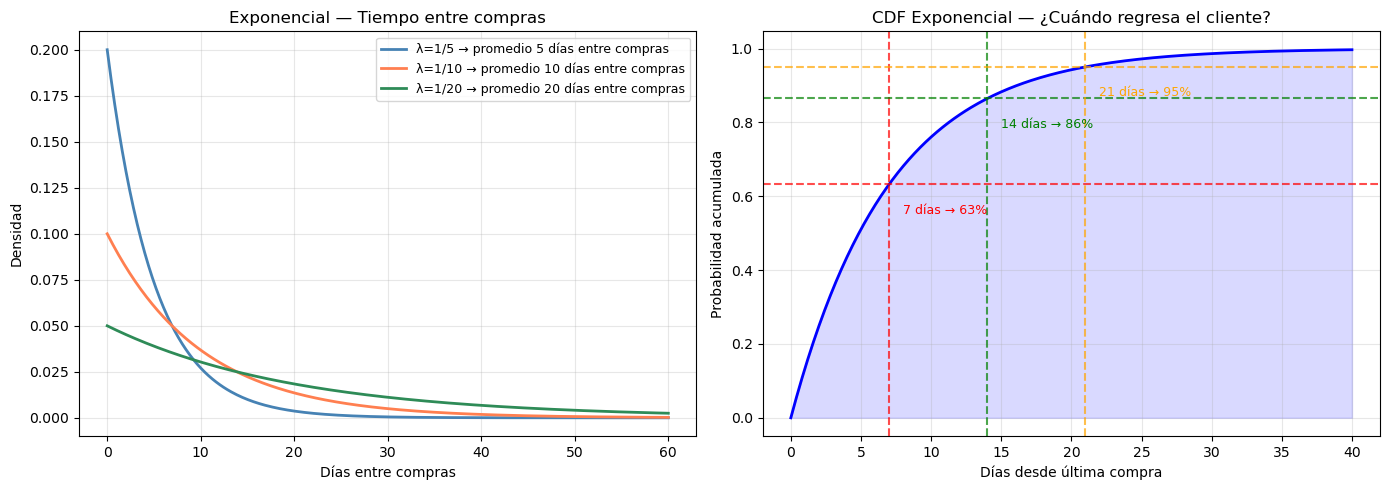

P(regresa en ≤  7 días) = 63.2%
P(regresa en ≤ 14 días) = 86.5%
P(regresa en ≤ 21 días) = 95.0%


In [11]:
# ============================================================
# S4.2 — DISTRIBUCIÓN EXPONENCIAL
# ============================================================

# Modela: tiempo ENTRE eventos (complemento de Poisson)
# Si Poisson dice "cuántos eventos por hora" →
# Exponencial dice "cuánto tiempo hasta el siguiente evento"
# Parámetro: λ (misma lambda — tasa de ocurrencia)
# Media = 1/λ

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Curvas para diferentes tasas ---
ax = axes[0]
x = np.linspace(0, 60, 300)

configs = [
    (1/5,  'steelblue', 'λ=1/5 → promedio 5 días entre compras'),
    (1/10, 'coral',     'λ=1/10 → promedio 10 días entre compras'),
    (1/20, 'seagreen',  'λ=1/20 → promedio 20 días entre compras'),
]

for lam, color, label in configs:
    pdf_exp = stats.expon.pdf(x, scale=1/lam)
    ax.plot(x, pdf_exp, color=color, linewidth=2, label=label)

ax.set_title('Exponencial — Tiempo entre compras')
ax.set_xlabel('Días entre compras')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)

# --- Plot 2: Caso retail — probabilidad acumulada ---
ax = axes[1]
lam_retail = 1/7   # promedio: 1 compra cada 7 días

x2 = np.linspace(0, 40, 300)
cdf = stats.expon.cdf(x2, scale=1/lam_retail)  # CDF = probabilidad acumulada

ax.plot(x2, cdf, 'b-', linewidth=2)
ax.fill_between(x2, cdf, alpha=0.15, color='blue')

# Marcar probabilidades clave
for dias, color in [(7, 'red'), (14, 'green'), (21, 'orange')]:
    p = stats.expon.cdf(dias, scale=1/lam_retail)
    ax.axvline(dias, color=color, linestyle='--', alpha=0.7)
    ax.axhline(p, color=color, linestyle='--', alpha=0.7)
    ax.annotate(f'{dias} días → {p*100:.0f}%',
                xy=(dias, p), xytext=(dias+1, p-0.08),
                fontsize=9, color=color)

ax.set_title('CDF Exponencial — ¿Cuándo regresa el cliente?')
ax.set_xlabel('Días desde última compra')
ax.set_ylabel('Probabilidad acumulada')

plt.tight_layout()
plt.savefig('../reports/S4.2_exponencial.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación
lam = 1/7
for dias in [7, 14, 21]:
    p = stats.expon.cdf(dias, scale=1/lam)
    print(f"P(regresa en ≤ {dias:2d} días) = {p*100:.1f}%")

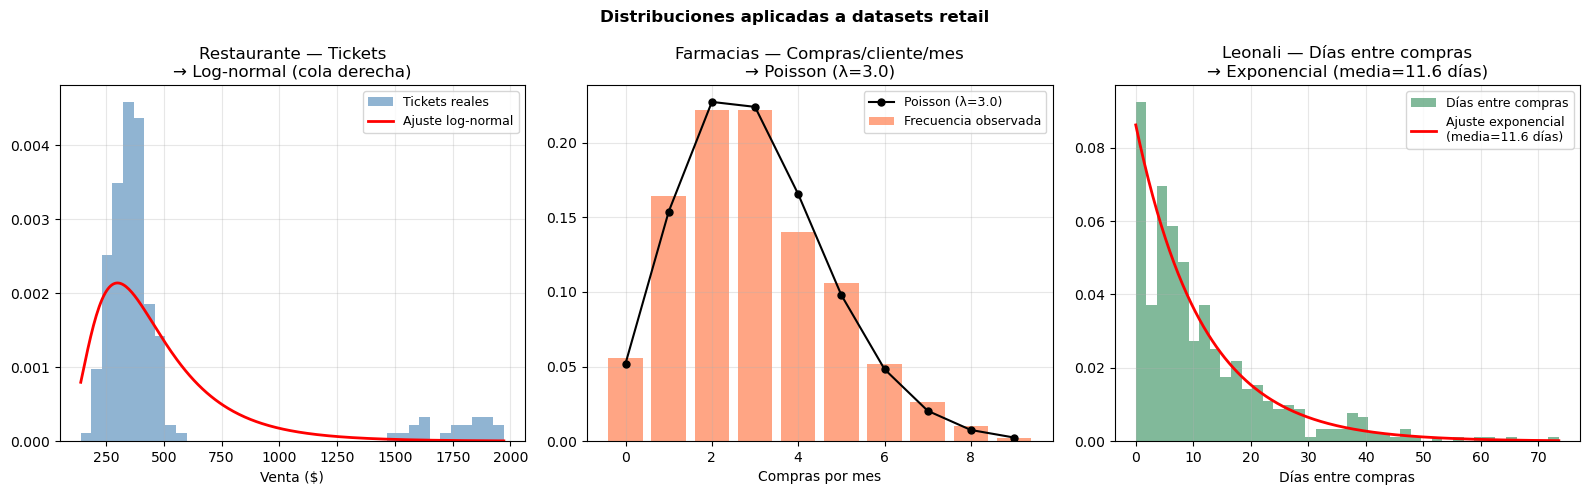

=== RESUMEN: qué distribución usar en cada caso ===
Tickets de venta     → Log-normal  (cola derecha, siempre positivo)
Compras por cliente  → Poisson     (conteos enteros, tasa constante)
Tiempo entre compras → Exponencial (esperas, siempre positivo)
Errores de medición  → Normal      (simétrica, muchos fenómenos naturales)


In [12]:
# ============================================================
# S4.2 — CONEXIÓN CON DATASETS REALES
# ============================================================
# Verificamos qué distribución describe mejor cada variable

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

np.random.seed(42)

# --- Dataset 1: Tickets restaurante (simulado S4.1) ---
tickets = np.concatenate([
    np.random.normal(350, 80, 180),
    np.random.normal(1800, 200, 20)
]).clip(50)

ax = axes[0]
ax.hist(tickets, bins=40, density=True, alpha=0.6,
        color='steelblue', label='Tickets reales')

# Ajustar log-normal
shape, loc, scale = stats.lognorm.fit(tickets, floc=0)
x = np.linspace(tickets.min(), tickets.max(), 300)
ax.plot(x, stats.lognorm.pdf(x, shape, loc, scale),
        'r-', linewidth=2, label='Ajuste log-normal')
ax.set_title('Restaurante — Tickets\n→ Log-normal (cola derecha)')
ax.set_xlabel('Venta ($)')
ax.legend(fontsize=9)

# --- Dataset 2: Frecuencia de compras (Farmacias simulado) ---
# Simulamos compras por cliente por mes
compras_mes = np.random.poisson(lam=3, size=500)

ax = axes[1]
valores, conteos = np.unique(compras_mes, return_counts=True)
ax.bar(valores, conteos/len(compras_mes), color='coral',
       alpha=0.7, label='Frecuencia observada')

# Ajustar Poisson
lam_est = compras_mes.mean()
k = np.arange(0, compras_mes.max()+1)
ax.plot(k, stats.poisson.pmf(k, lam_est), 'ko-',
        markersize=5, linewidth=1.5, label=f'Poisson (λ={lam_est:.1f})')
ax.set_title(f'Farmacias — Compras/cliente/mes\n→ Poisson (λ={lam_est:.1f})')
ax.set_xlabel('Compras por mes')
ax.legend(fontsize=9)

# --- Dataset 3: Tiempo entre compras (Leonali simulado) ---
dias_entre = np.random.exponential(scale=12, size=500)

ax = axes[2]
ax.hist(dias_entre, bins=40, density=True, alpha=0.6,
        color='seagreen', label='Días entre compras')

# Ajustar exponencial
loc_e, scale_e = stats.expon.fit(dias_entre, floc=0)
x_e = np.linspace(0, dias_entre.max(), 300)
ax.plot(x_e, stats.expon.pdf(x_e, loc_e, scale_e),
        'r-', linewidth=2, label=f'Ajuste exponencial\n(media={scale_e:.1f} días)')
ax.set_title(f'Leonali — Días entre compras\n→ Exponencial (media={scale_e:.1f} días)')
ax.set_xlabel('Días entre compras')
ax.legend(fontsize=9)

plt.suptitle('Distribuciones aplicadas a datasets retail',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/S4.2_distribuciones_retail.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== RESUMEN: qué distribución usar en cada caso ===")
print(f"Tickets de venta     → Log-normal  (cola derecha, siempre positivo)")
print(f"Compras por cliente  → Poisson     (conteos enteros, tasa constante)")
print(f"Tiempo entre compras → Exponencial (esperas, siempre positivo)")
print(f"Errores de medición  → Normal      (simétrica, muchos fenómenos naturales)")